In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import hilbert

# --------------------------------------------------
# PATHS
# --------------------------------------------------

SOLID_DIR = Path(
    "/media/dysco/New Volume1/Neeraj/varflexi solver/results/results 2/results-reisner-heaving-span/solid/v18_reisner_mindlin_plate/"
)

FLUID_DIR = Path(
    "/media/dysco/New Volume1/Neeraj/varflexi solver/results/results 2/results-reisner-heaving-span/fluid/v9"
)

COUPLING_DIR = Path(
    "/media/dysco/New Volume1/Neeraj/varflexi solver/results/results 2/results-reisner-heaving-span/coupling"
)

FIG_DIR = Path(
    "/home/dysco/FLOWUnsteady/VarFLEXI-rVPM-Fenics/final_plots/heaving_validation/"
)

FIG_DIR.mkdir(
    parents=True,
    exist_ok=True
)

In [2]:
# --------------------------------------------------
# PHYSICAL PARAMETERS
# --------------------------------------------------

span = 0.30
chord = 0.10

Uinf = 4.43

kG = 1.82

freq = kG*Uinf/(np.pi*chord)

omega = 2*np.pi*freq

print("Frequency =",freq)

Frequency = 25.664052883454307


In [3]:
diag = pd.read_csv(
    SOLID_DIR/"solid_v18_diagnostics.csv"
)

diag.head()

,step,time,u_tip,E_elas,E_kin,E_damp,E_tot,work_Wf,work_Ws,work_rel_error
0,1,0.0003,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
1,2,0.0006,1.215662e-20,8.702269e-11,2.751737e-10,2.284057e-12,3.644805e-10,0.000000e+00,0.000000e+00,0.000000
2,3,0.0009,-1.600405e-17,6.716622e-10,1.852363e-09,5.652321e-12,2.529677e-09,-3.657042e-17,-3.241496e-17,0.041555
3,4,0.0012,-1.601338e-16,1.900902e-09,5.036349e-09,9.642802e-12,6.946894e-09,-9.454475e-16,-8.866126e-16,0.062230
4,5,0.0015,-8.212356e-16,3.876516e-09,1.023460e-08,1.421951e-11,1.412534e-08,-7.359359e-15,-7.105485e-15,0.034497


In [4]:
time = diag["time"].values

tip_disp = diag["u_tip"].values

E_elas = diag["E_elas"].values
E_kin  = diag["E_kin"].values
E_damp = diag["E_damp"].values
E_tot  = diag["E_tot"].values

Wf = diag["work_Wf"].values
Ws = diag["work_Ws"].values
work_err = diag["work_rel_error"].values

In [5]:
a_root = 0.175*chord

root_disp = a_root*np.cos(
    omega*time
)

In [6]:
root_nd = root_disp/a_root

tip_nd = tip_disp/a_root

Tcycle = 1/freq

time_nd = time/Tcycle

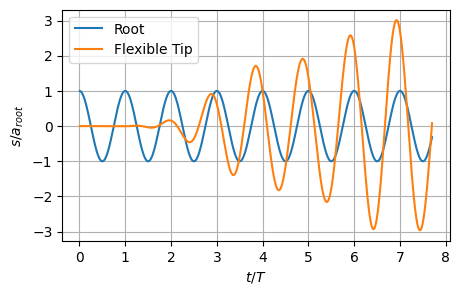

In [7]:
fig,ax = plt.subplots(
    figsize=(5,3)
)

ax.plot(
    time_nd,
    root_nd,
    label="Root"
)

ax.plot(
    time_nd,
    tip_nd,
    label="Flexible Tip"
)

ax.set_xlabel(
    r"$t/T$"
)

ax.set_ylabel(
    r"$s/a_{root}$"
)

ax.grid(True)

ax.legend()

fig.savefig(
    FIG_DIR/"validation_tip_displacement.pdf"
)

plt.show()

In [8]:
Aroot = (
    root_disp.max()
    -
    root_disp.min()
)/2

Atip = (
    tip_disp.max()
    -
    tip_disp.min()
)/2

amp_ratio = Atip/Aroot

print(
    "Tip amplification ratio =",
    amp_ratio
)

Tip amplification ratio = 2.9837521831870157


In [9]:
analytic_root = hilbert(root_disp)
analytic_tip  = hilbert(tip_disp)

phase_root = np.unwrap(
    np.angle(analytic_root)
)

phase_tip = np.unwrap(
    np.angle(analytic_tip)
)

phase_lag = np.mean(
    phase_tip-phase_root
)

print(
    "Mean phase lag [rad] =",
    phase_lag
)

print(
    "Mean phase lag [deg] =",
    np.degrees(phase_lag)
)

Mean phase lag [rad] = -10.77900416323943
Mean phase lag [deg] = -617.5914459075627


In [10]:
dt = time[1]-time[0]

signal = tip_disp - np.mean(tip_disp)

fft_vals = np.fft.rfft(signal)

fft_freq = np.fft.rfftfreq(
    len(signal),
    d=dt
)

fft_amp = np.abs(fft_vals)

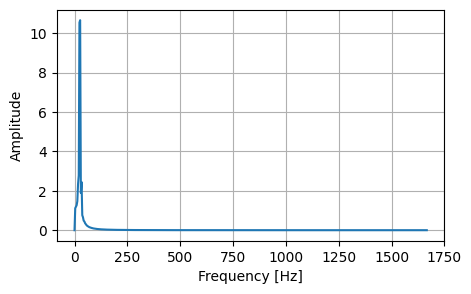

In [11]:
fig,ax = plt.subplots(
    figsize=(5,3)
)

ax.plot(
    fft_freq,
    fft_amp
)

ax.set_xlabel(
    "Frequency [Hz]"
)

ax.set_ylabel(
    "Amplitude"
)

ax.grid(True)

fig.savefig(
    FIG_DIR/"fft_tip_response.pdf"
)

plt.show()

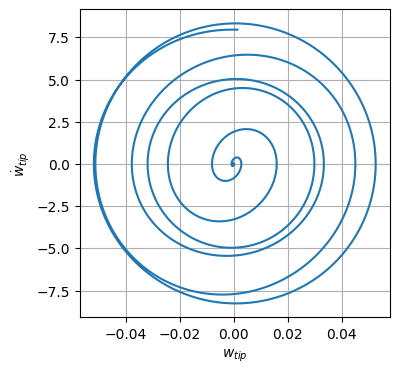

In [12]:
vel_tip = np.gradient(
    tip_disp,
    dt
)

fig,ax = plt.subplots(
    figsize=(4,4)
)

ax.plot(
    tip_disp,
    vel_tip
)

ax.set_xlabel(
    r"$w_{tip}$"
)

ax.set_ylabel(
    r"$\dot w_{tip}$"
)

ax.grid(True)

fig.savefig(
    FIG_DIR/"phase_space.pdf"
)

plt.show()

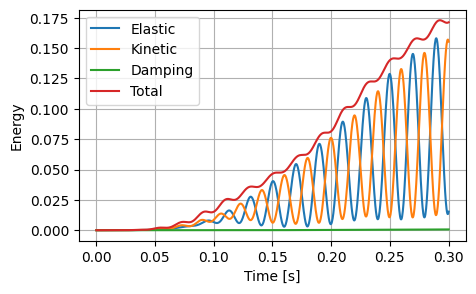

In [13]:
fig,ax = plt.subplots(
    figsize=(5,3)
)

ax.plot(
    time,
    E_elas,
    label="Elastic"
)

ax.plot(
    time,
    E_kin,
    label="Kinetic"
)

ax.plot(
    time,
    E_damp,
    label="Damping"
)

ax.plot(
    time,
    E_tot,
    label="Total"
)

ax.legend()

ax.grid(True)

ax.set_xlabel("Time [s]")

ax.set_ylabel("Energy")

fig.savefig(
    FIG_DIR/"energy_history.pdf"
)

plt.show()

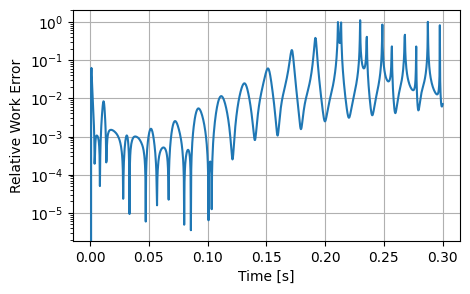

In [14]:
fig,ax = plt.subplots(
    figsize=(5,3)
)

ax.semilogy(
    time,
    np.abs(work_err)
)

ax.set_xlabel(
    "Time [s]"
)

ax.set_ylabel(
    "Relative Work Error"
)

ax.grid(True)

fig.savefig(
    FIG_DIR/"work_conservation_error.pdf"
)

plt.show()

In [15]:
print(
    "Mean work error =",
    np.mean(work_err)
)

print(
    "Max work error =",
    np.max(work_err)
)

print(
    "RMS work error =",
    np.sqrt(
        np.mean(work_err**2)
    )
)

Mean work error = 0.03348961734421067
Max work error = 1.104188607695
RMS work error = 0.10319381026287947


In [16]:
coupling = pd.read_csv(
    COUPLING_DIR/"coupling_history.csv"
)

coupling.head()

,step,n_forces,force_relax_used,force_residual,sample_fx,sample_fy,sample_fz
0,1,80,0.2,0.000000,0.000000e+00,0.000000e+00,0.000000e+00
1,2,80,0.2,1.000000,-3.549688e-30,0.000000e+00,7.250911e-17
2,3,80,0.2,1.000002,6.791172e-24,-3.065941e-15,-8.455479e-11
3,4,80,0.2,0.962151,3.785432e-20,-5.245422e-14,-4.616609e-10
4,5,80,0.2,0.919561,2.279529e-18,-2.730269e-13,-1.356271e-09


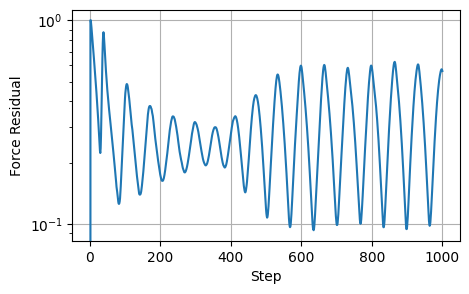

In [17]:
fig,ax = plt.subplots(
    figsize=(5,3)
)

ax.semilogy(
    coupling["step"],
    coupling["force_residual"]
)

ax.set_xlabel(
    "Step"
)

ax.set_ylabel(
    "Force Residual"
)

ax.grid(True)

fig.savefig(
    FIG_DIR/"coupling_residual.pdf"
)

plt.show()

In [18]:
json_file = (
    COUPLING_DIR/
    "forces_sent_received_history.jsonl"
)

Fx = []
Fy = []
Fz = []
steps = []

with open(json_file,"r") as fp:

    for line in fp:

        rec = json.loads(line)

        f0 = rec["force_sent"][0]

        Fx.append(f0[0])
        Fy.append(f0[1])
        Fz.append(f0[2])

        steps.append(
            rec["step"]
        )

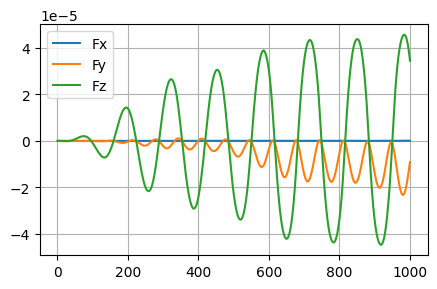

In [19]:
fig,ax = plt.subplots(
    figsize=(5,3)
)

ax.plot(steps,Fx,label="Fx")
ax.plot(steps,Fy,label="Fy")
ax.plot(steps,Fz,label="Fz")

ax.legend()

ax.grid(True)

fig.savefig(
    FIG_DIR/"force_history_cp0.pdf"
)

plt.show()